# 01 - Preprocesamiento

Limpieza del dataset maestro, distribución de clases, decorrelación y construcción de los datasets M7, M4 y binarios (split primero, SMOTE solo en train).

In [1]:
import pandas as pd

from csp_perovskites import config, io, plotting, preprocessing as pp, datasets as ds

## Dataset maestro y polimorfismo

In [2]:
df = pp.clean_master(io.load_master())
print(df.shape, "| fórmulas únicas:", df["Formula"].nunique())
pp.class_count_per_formula(df).value_counts().sort_index()

(6417, 41) | fórmulas únicas: 5279


class_count
1    4502
2     540
3     148
4      62
5      20
6       6
7       1
Name: count, dtype: int64

PosixPath('/home/david/Desktop/IsabelN/CSP_Perovskites/results/figures/grouped_bar_log.png')

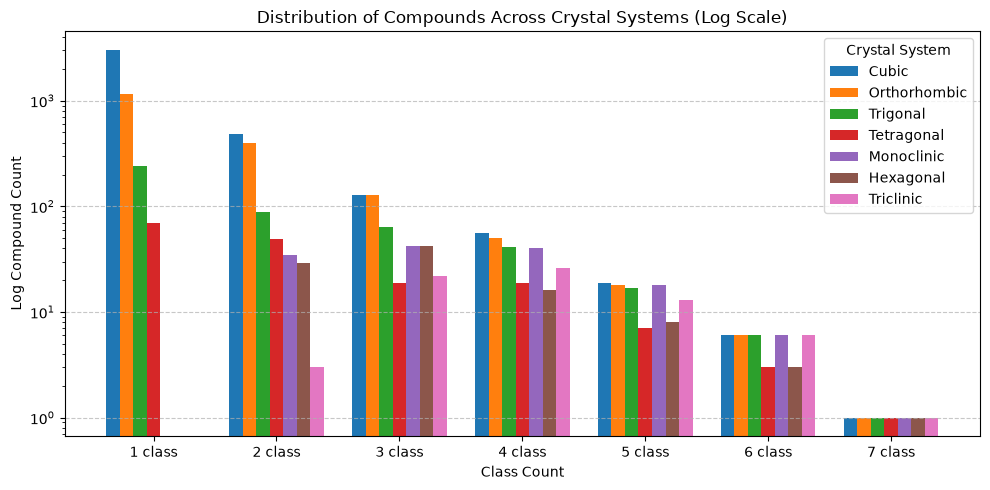

In [3]:
fig = plotting.class_count_log_bar(pp.class_count_table(df))
io.save_fig(fig, "grouped_bar_log.png", dpi=300)

PosixPath('/home/david/Desktop/IsabelN/CSP_Perovskites/results/figures/crystal_systems_pie.png')

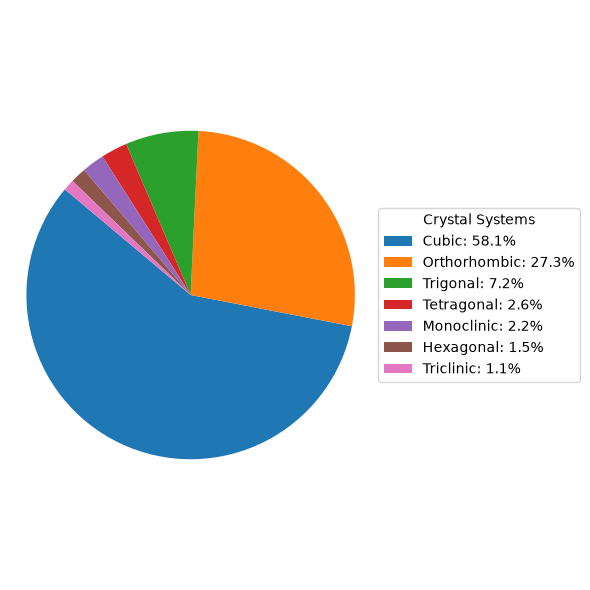

In [4]:
fig = plotting.class_pie(df[config.TARGET])
io.save_fig(fig, "crystal_systems_pie.png")

## Correlación y decorrelación (|r| > 0.9, conservando los 12 descriptores de ingeniería)

Eliminadas: ['r_A6', 'r_B', 'EN_A', 'EN_B', 'R_A', 'MP_A', 'CR_A', 'R_B', 'MP_B', 'CR_B']
27 features: ['ARR_A', 'ARR_B', 'MPR_A', 'MPR_B', 'END_A', 'END_B', 'OF', 't', 'BL_AB', 'BL_AX', 'BL_BX', 'ENR', 'r_A12', 'IE_A', 'D_A', 'TC_A', 'VLC_A', 'BP_A', 'VR_A', 'AM_A', 'IE_B', 'D_B', 'TC_B', 'VLC_B', 'BP_B', 'VR_B', 'AM_B']


PosixPath('/home/david/Desktop/IsabelN/CSP_Perovskites/data/processed/Master_decorrelated.csv')

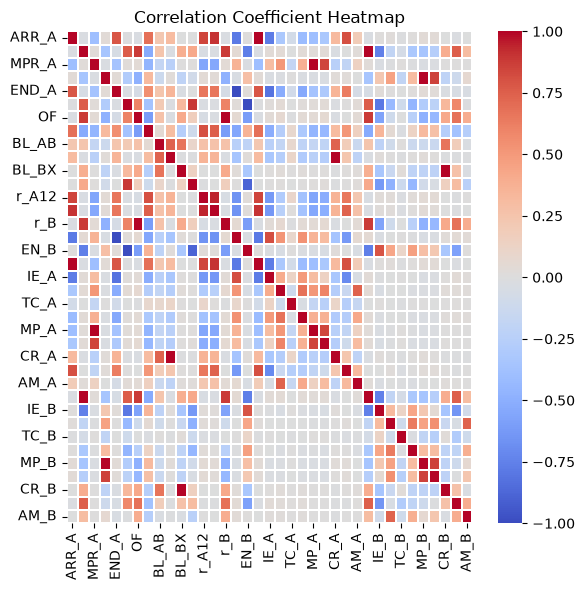

In [5]:
fig = plotting.corr_heatmap(pp.correlation_matrix(df))
io.save_fig(fig, "correlation_heatmap.png")

df_decor, dropped = pp.decorrelate(df, threshold=config.CORR_THRESHOLD, keep=config.ENGINEERED_FEATURES)
print("Eliminadas:", dropped)
print(len(pp.feature_columns(df_decor)), "features:", pp.feature_columns(df_decor))
io.save_csv(df_decor, config.PROCESSED_DIR / "Master_decorrelated.csv")

## M7 (7 clases)

Split estratificado 80/20, SMOTE en train y eliminación de vectores con etiquetas en conflicto en train. Se guarda el split con `RANDOM_STATE` como referencia; los experimentos regeneran un split por corrida.

train: (19532, 28) | test (real): (1284, 28)


PosixPath('/home/david/Desktop/IsabelN/CSP_Perovskites/results/figures/M7_train_counts.png')

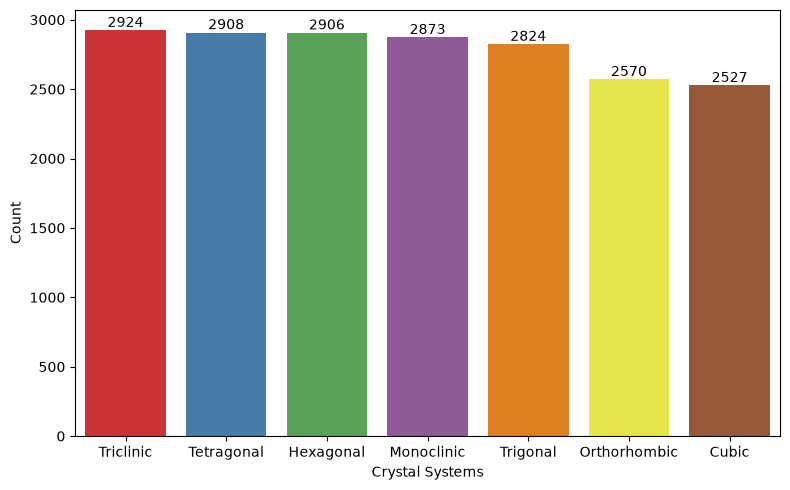

In [6]:
m7 = ds.make_m7_split(df_decor, seed=config.RANDOM_STATE)
train, test = ds.split_to_frames(m7)
io.save_csv(train, config.PROCESSED_DIR / "M7_train.csv")
io.save_csv(test, config.PROCESSED_DIR / "M7_test.csv")
print("train:", train.shape, "| test (real):", test.shape)
fig = plotting.counts_bar(m7.y_train)
io.save_fig(fig, "M7_train_counts.png")

## M4 (compuestos con una sola etiqueta, 4 clases)

train: (9712, 28) | test (real): (901, 28)


PosixPath('/home/david/Desktop/IsabelN/CSP_Perovskites/results/figures/M4_train_counts.png')

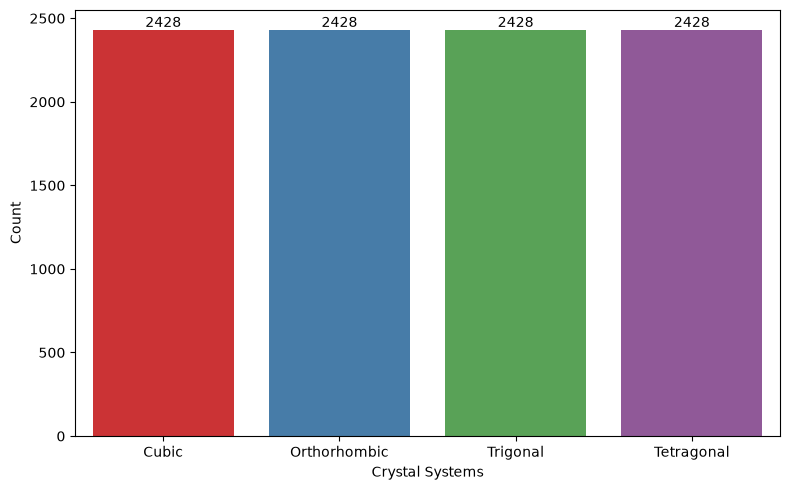

In [7]:
m4 = ds.make_m4_split(df_decor, seed=config.RANDOM_STATE)
train, test = ds.split_to_frames(m4)
io.save_csv(train, config.PROCESSED_DIR / "M4_train.csv")
io.save_csv(test, config.PROCESSED_DIR / "M4_test.csv")
print("train:", train.shape, "| test (real):", test.shape)
fig = plotting.counts_bar(m4.y_train)
io.save_fig(fig, "M4_train_counts.png")

## Codificación multietiqueta y datasets binarios (one-vs-all)

In [8]:
df_encoded = pp.encode_multilabel(df)
io.save_csv(df_encoded, config.PROCESSED_DIR / "Master_encoded.csv")

binary = ds.make_binary_splits(df_encoded, seed=config.RANDOM_STATE)
for system, (X_bal, y_bal) in binary.train.items():
    io.save_csv(X_bal.assign(**{system: y_bal.to_numpy()}), config.BINARY_DIR / f"balanced_{system}.csv")
    print(f"{system:<13} {len(y_bal):>5} muestras  {y_bal.value_counts().to_dict()}")

io.save_csv(pd.concat([binary.formulas_test, binary.X_test, binary.Y_test], axis=1),
            config.BINARY_DIR / "multilabel_test.csv")
print("Test multietiqueta:", binary.X_test.shape)

Cubic          5936 muestras  {0: 2968, 1: 2968}
Orthorhombic   5606 muestras  {1: 2803, 0: 2803}
Trigonal       7694 muestras  {0: 3847, 1: 3847}
Tetragonal     8174 muestras  {0: 4087, 1: 4087}
Monoclinic     8208 muestras  {0: 4104, 1: 4104}
Hexagonal      8270 muestras  {0: 4135, 1: 4135}
Triclinic      8326 muestras  {0: 4163, 1: 4163}
Test multietiqueta: (1056, 37)
